In [41]:
from scipy.stats import shapiro, levene
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from models_ import *
from utils import *

from flow_model import *

from flow_utils import *

from forward_inverse import *
import torch.nn.functional as F
from torch.nn.functional import pairwise_distance,cosine_similarity
import os

# helper

In [42]:
def set_seed(seed: int = 42):
    random.seed(seed)                       
    np.random.seed(seed)                   
    torch.manual_seed(seed)                

    if torch.backends.mps.is_available():
  
        print("Using MPS: Seed fixed for reproducibility")
    elif torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False   
set_seed(42)

Using MPS: Seed fixed for reproducibility


In [43]:
def load_all_model_families(model_families, save_dir):

    loaded_families = {}

    for family_name, model_dict in model_families.items():
        folder_path = os.path.join(save_dir, family_name)
        if not os.path.exists(folder_path):
            print(f"❌ folder {folder_path} not found, skipping.")
            continue

        loaded_families[family_name] = {}

        for model_name, model_obj in model_dict.items():
            if isinstance(model_obj, dict):
                loaded_families[family_name][model_name] = {}
                for subname, submodel in model_obj.items():
                    filename = f"{model_name}_{subname}.pth"
                    path = os.path.join(folder_path, filename)
                    if os.path.exists(path):
                        submodel.load_state_dict(torch.load(path, map_location='cpu'))
                        submodel.eval()
                        loaded_families[family_name][model_name][subname] = submodel
                        print(f"✅ Loaded {family_name}/{model_name}_{subname}")
                    else:
                        print(f"❌ Missing: {path}")
            else:
                filename = f"{model_name}.pth"
                path = os.path.join(folder_path, filename)
                if os.path.exists(path):
                    model_obj.load_state_dict(torch.load(path, map_location='cpu'))
                    model_obj.eval()
                    loaded_families[family_name][model_name] = model_obj
                    print(f"✅ Loaded {family_name}/{model_name}")
                else:
                    print(f"❌ Missing: {path}")

    return loaded_families



# model_def

In [44]:
def build_minivit():
    return MiniVisionTransformer(d_in=1, d_out=16, d_hidden=32, patch_size=4,
                                 num_heads=4, img_size=32)

def build_unet():
    return MiniUNet(d_in=1, d_out=16, d_hidden=26, kernel_num=3, img_size=32)

def build_pcamlp():
    return PCAMLP(d_in=32*32, d_out=16, d_hidden=57, img_size=32, n_components=256)

def build_pcamlp_inverse():
    return PCAMLP(d_in=32*32, d_out=16, d_hidden=58, img_size=32, n_components=256)

def build_mlp():
    return MLPExtractor(d_in=32*32, d_out=14, d_hidden=16, img_size=32)

def build_decoder(d_out):
    return Utdecoder(d_out, 1)


def lvf(extractor, d_out): return LatentVecField(extractor, d_out)
def vf(encoder, decoder): return vecfield(encoder, decoder)


def build_latentmodels():
    return {
        "MiniViT": {"forward": lvf(build_minivit(), 16), "inverse": build_minivit()},
        "ConvNet": {"forward": lvf(build_unet(), 16), "inverse": build_unet()},
        "PCA_MLP": {"forward": lvf(build_pcamlp(), 16), "inverse": build_pcamlp_inverse()},
        "MLP": {"forward": lvf(build_mlp(), 14), "inverse": build_mlp()},
    }

def build_inversemodels(latentmodels):
    return {
        "MiniViT": {"decoder": build_decoder(16), "inverse": latentmodels["MiniViT"]["inverse"]},
        "ConvNet": {"decoder": build_decoder(16), "inverse": latentmodels["ConvNet"]["inverse"]},
        "PCA_MLP": {"decoder": build_decoder(16), "inverse": latentmodels["PCA_MLP"]["inverse"]},
        "MLP": {"decoder": build_decoder(14), "inverse": latentmodels["MLP"]["inverse"]},
    }

def build_mms(latentmodels, inversemodels):
    return {
        "MiniViT": vf(latentmodels["MiniViT"]["forward"], inversemodels["MiniViT"]["decoder"]),
        "MiniUNet": vf(latentmodels["ConvNet"]["forward"], inversemodels["ConvNet"]["decoder"]),
        "PCAMLP": vf(latentmodels["PCA_MLP"]["forward"], inversemodels["PCA_MLP"]["decoder"]),
        "MLP": vf(latentmodels["MLP"]["forward"], inversemodels["MLP"]["decoder"]),
    }

def build_cms(latentmodels, inversemodels):
    return {
        "MiniViT": {"forward": latentmodels["MiniViT"]["forward"], "inverse": latentmodels["MiniViT"]["inverse"], "decoder": inversemodels["MiniViT"]["decoder"]},
        "UNet": {"forward": latentmodels["ConvNet"]["forward"], "inverse": latentmodels["ConvNet"]["inverse"], "decoder": inversemodels["ConvNet"]["decoder"]},
        "PCA_MLP": {"forward": latentmodels["PCA_MLP"]["forward"], "inverse": latentmodels["PCA_MLP"]["inverse"], "decoder": inversemodels["PCA_MLP"]["decoder"]},
        "MLP": {"forward": latentmodels["MLP"]["forward"], "inverse": latentmodels["MLP"]["inverse"], "decoder": inversemodels["MLP"]["decoder"]},
    }

def build_fullmodels():
    return {
        "MiniViT": {"forward": lvf(build_minivit(), 16), "inverse": build_minivit(), "decoder": build_decoder(16)},
        "UNet": {"forward": lvf(build_unet(), 16), "inverse": build_unet(), "decoder": build_decoder(16)},
        "PCA_MLP": {"forward": lvf(build_pcamlp(), 16), "inverse": build_pcamlp_inverse(), "decoder": build_decoder(16)},
        "MLP": {"forward": lvf(build_mlp(), 14), "inverse": build_mlp(), "decoder": build_decoder(14)}
    }

def build_ams(fullmodels):
    return {
        "MiniViT": vf(fullmodels["MiniViT"]["forward"], fullmodels["MiniViT"]["decoder"]),
        "MiniUNet": vf(fullmodels["UNet"]["forward"], fullmodels["UNet"]["decoder"]),
        "PCAMLP": vf(fullmodels["PCA_MLP"]["forward"], fullmodels["PCA_MLP"]["decoder"]),
        "MLP": vf(fullmodels["MLP"]["forward"], fullmodels["MLP"]["decoder"]),
    }

def build_models_full():
    return {
        "MiniViT": vf(lvf(build_minivit(), 16), build_decoder(16)),
        "MiniUNet": vf(lvf(build_unet(), 16), build_decoder(16)),
        "PCAMLP": vf(lvf(build_pcamlp(), 16), build_decoder(16)),
        "MLP": vf(lvf(build_mlp(), 14), build_decoder(14)),
    }

In [45]:
latentmodels = build_latentmodels()
inversemodels = build_inversemodels(build_latentmodels())
mms = build_mms(build_latentmodels(), build_inversemodels(build_latentmodels()))
cms = build_cms(build_latentmodels(), build_inversemodels(build_latentmodels()))
fullmodels = build_fullmodels()
ams = build_ams(build_fullmodels())
models_full = build_models_full()

latentmodels2 = build_latentmodels()
inversemodels2 = build_inversemodels(build_latentmodels())
mms2 = build_mms(build_latentmodels(), build_inversemodels(build_latentmodels()))




# load

In [6]:
latent_model=load_all_model_families({"latentmodels": latentmodels}, save_dir="saved_models1")['latentmodels']
latent_model2=load_all_model_families({"latentmodels2": latentmodels2}, save_dir="saved_models1")['latentmodels2']
inverse_model=load_all_model_families({"inversemodels": inversemodels}, save_dir="saved_models1")['inversemodels']
inverse_model2=load_all_model_families({"inversemodels2": inversemodels2}, save_dir="saved_models1")['inversemodels2']
ms=load_all_model_families({"mms": mms}, save_dir="saved_models1")['mms']
ms2=load_all_model_families({"mms2": mms2}, save_dir="saved_models1")['mms2']
cm=load_all_model_families({"cms": cms}, save_dir="saved_models1")['cms']
models_f=load_all_model_families({"models_full": models_full}, save_dir="saved_models1")['models_full']
full_m=load_all_model_families({"fullmodels": fullmodels}, save_dir="saved_models1")['fullmodels']

✅ Loaded latentmodels/MiniViT_forward
✅ Loaded latentmodels/MiniViT_inverse
✅ Loaded latentmodels/ConvNet_forward
✅ Loaded latentmodels/ConvNet_inverse
✅ Loaded latentmodels/PCA_MLP_forward
✅ Loaded latentmodels/PCA_MLP_inverse
✅ Loaded latentmodels/MLP_forward
✅ Loaded latentmodels/MLP_inverse
✅ Loaded latentmodels2/MiniViT_forward
✅ Loaded latentmodels2/MiniViT_inverse
✅ Loaded latentmodels2/ConvNet_forward
✅ Loaded latentmodels2/ConvNet_inverse
✅ Loaded latentmodels2/PCA_MLP_forward
✅ Loaded latentmodels2/PCA_MLP_inverse
✅ Loaded latentmodels2/MLP_forward
✅ Loaded latentmodels2/MLP_inverse
✅ Loaded inversemodels/MiniViT_decoder
✅ Loaded inversemodels/MiniViT_inverse
✅ Loaded inversemodels/ConvNet_decoder
✅ Loaded inversemodels/ConvNet_inverse
✅ Loaded inversemodels/PCA_MLP_decoder
✅ Loaded inversemodels/PCA_MLP_inverse
✅ Loaded inversemodels/MLP_decoder
✅ Loaded inversemodels/MLP_inverse
✅ Loaded inversemodels2/MiniViT_decoder
✅ Loaded inversemodels2/MiniViT_inverse
✅ Loaded inverse

# expr

## helper func


In [16]:
from torch.distributions import MultivariateNormal
def compute_loss(x,y):
    return einsum(torch.square(x - y), 'b ... -> b').mean()
def compute_mse(x, y):
    return F.mse_loss(x, y)


def compute_cosine_similarity(x, y):
    x_flat = rearrange(x, 'b ... -> b (...)')
    y_flat = rearrange(y, 'b ... -> b (...)')
    sim = F.cosine_similarity(x_flat, y_flat, dim=-1)
    return sim.mean()


def compute_kl_divergence(x, y):
    x_flat = rearrange(x, 'b ... -> b (...)')
    y_flat = rearrange(y, 'b ... -> b (...)')

    x_mean = x_flat.mean(dim=0)
    y_mean = y_flat.mean(dim=0)
    x_cov = torch.cov(x_flat.T)
    y_cov = torch.cov(y_flat.T)

    dist_x = MultivariateNormal(x_mean, x_cov + 1e-4 * torch.eye(x_cov.shape[0]))
    dist_y = MultivariateNormal(y_mean, y_cov + 1e-4 * torch.eye(y_cov.shape[0]))
    
    kl_xy = torch.distributions.kl.kl_divergence(dist_x, dist_y)
    kl_yx = torch.distributions.kl.kl_divergence(dist_y, dist_x)
    return kl_xy, kl_yx


def compute_js_divergence(x, y):
    kl1, kl2 = compute_kl_divergence(x, y)
    return 0.5 * (kl1 + kl2)


def compute_bhattacharyya_distance(x, y):
    x_flat = rearrange(x, 'b ... -> b (...)')
    y_flat = rearrange(y, 'b ... -> b (...)')

    x_mean = x_flat.mean(dim=0)
    y_mean = y_flat.mean(dim=0)
    x_cov = torch.cov(x_flat.T)
    y_cov = torch.cov(y_flat.T)

    cov_avg = 0.5 * (x_cov + y_cov + 1e-4 * torch.eye(x_cov.shape[0]))

    mean_diff = (x_mean - y_mean).unsqueeze(0)
    inv_cov_avg = torch.linalg.pinv(cov_avg)
    term = mean_diff @ inv_cov_avg @ mean_diff.T
    dist = 0.125 * term.squeeze() + 0.5 * torch.logdet(cov_avg) - 0.25 * (torch.logdet(x_cov) + torch.logdet(y_cov))
    return dist

def compute_wasserstein_distance(x, y):
    x_flat = rearrange(x, 'b ... -> b (...)')
    y_flat = rearrange(y, 'b ... -> b (...)')
    return torch.norm(x_flat - y_flat, p=2, dim=-1).mean()

In [17]:
import pandas as pd

results = []

def evaluate_pair(output1, output2):
    kl1, kl2 = compute_kl_divergence(output1, output2)
    return {
        "Loss": compute_loss(output1, output2),
        "MSE": compute_mse(output1, output2),
        "CosineSimilarity": compute_cosine_similarity(output1, output2),
        "KL(x||y)": kl1,
        "KL(y||x)": kl2,
        "JS Divergence": compute_js_divergence(output1, output2),
        "Bhattacharyya": compute_bhattacharyya_distance(output1, output2),
        "Wasserstein": compute_wasserstein_distance(output1, output2)
    }

def record_evaluation(model_name, compare_name, model_type, output1, output2):
    metrics = evaluate_pair(output1, output2)
    metrics["Model"] = model_name
    metrics["Compare"] = compare_name
    metrics["Type"] = model_type
    results.append(metrics)


def evaluate_cm_models(key, model_group, x, t, y, ut_ref):
    forward_model = model_group["forward"]
    inverse_model = model_group["inverse"]
    decoder_model = model_group["decoder"]

    forward_model.eval()
    inverse_model.eval()
    decoder_model.eval()

    ut_forward = forward_model(x, t=t, y=y)
    ut_inverse = inverse_model(ut_ref)
    ut_theta = decoder_model(ut_forward, t=t, y=y)
    ut_theta_i = decoder_model(ut_inverse, t=t, y=y)

    record_evaluation(key, "ForwardDecoder vs Ref", "CM", ut_theta, ut_ref)
    record_evaluation(key, "InverseDecoder vs Ref", "CM", ut_theta_i, ut_ref)
    record_evaluation(key, "InverseDecoder vs ForwardDecoder", "CM", ut_theta_i, ut_theta)


def evaluate_dual_models(key, model_group, x, t, y, model_type="Dual"):
    model1 = model_group["forward"]
    model2 = model_group["inverse"]
    model1.eval()
    model2.eval()

    out1 = model1(x, t=t, y=y)
    out2 = model2(x)
    record_evaluation(key, "Forward vs Inverse", model_type, out1, out2)
    
def evaluate_single_model(key, model, x, t, y, ut_ref, model_type="Single"):
    model.eval()
    out = model(x, t=t, y=y)
    record_evaluation(key, "Model vs Ref", model_type, out, ut_ref)


## test

In [18]:
path = GaussianConditionalProbabilityPath(
    p_data = MNISTSampler(),
    p_simple_shape = [1, 32, 32],
    alpha = LinearAlpha(),
    beta = LinearBeta()
)

In [19]:
z, y = path.p_data.sample(2000) 
t = torch.rand(2000,1,1,1).to(z)
x = path.sample_conditional_path(z,t) 
ut_ref = path.conditional_vector_field(x,z,t) 

In [ ]:
latent_model=load_all_model_families({"latentmodels": latentmodels}, save_dir="saved_models1")['latentmodels']
latent_model2=load_all_model_families({"latentmodels2": latentmodels2}, save_dir="saved_models1")['latentmodels2']



In [20]:
for key, group in latent_model.items():
    evaluate_dual_models(key, group, x, t, y, model_type="path1_Latent")
for key, group in latent_model2.items():
    evaluate_dual_models(key, group, x, t, y, model_type="path2_Latent")


In [ ]:
inverse_model=load_all_model_families({"inversemodels": inversemodels}, save_dir="saved_models1")['inversemodels']
inverse_model2=load_all_model_families({"inversemodels2": inversemodels2}, save_dir="saved_models1")['inversemodels2']

In [22]:
for key, group in inverse_model.items():
    evaluate_dual_models(key, group, x, t, y, model_type="path1_inverse")
for key, group in inverse_model2.items():
    evaluate_dual_models(key, group, x, t, y, model_type="path2_inverse")

KeyError: 'forward'

In [ ]:
for key, model in ms.items():
    evaluate_single_model(key, model, x, t, y, ut_ref, model_type="path1_full")
    
for key, model in ms2.items():
    evaluate_single_model(key, model, x, t, y, ut_ref, model_type="path2_full")
    
for key, model in models_f.items():
    evaluate_single_model(key, model, x, t, y, ut_ref, model_type="path0_full")

In [262]:
for key, group in full_m.items():
    evaluate_cm_models(key, group, x, t, y, ut_ref)

In [39]:
import pandas as pd

results = []

In [29]:
for key, models_pair in latent_model.items():
    forward_model = models_pair["forward"]
    inverse_model = models_pair["inverse"]
    forward_model.eval()
    inverse_model.eval()
    

    # Forward and inverse outputs
    ut_forward = forward_model(x, t, y)
    ut_inverse = inverse_model(x)

    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss(ut_forward,ut_inverse)
    mse = compute_mse(ut_forward, ut_inverse)
    cos_sim=compute_cosine_similarity(ut_forward,ut_inverse)
    kl1,kl2=compute_kl_divergence(ut_forward, ut_inverse)
    #kl2=compute_kl_divergence(ut_forward,ut_inverse)
    js=compute_js_divergence(ut_forward,ut_inverse)
    bh=compute_bhattacharyya_distance(ut_forward,ut_inverse)
    wa=compute_wasserstein_distance(ut_forward,ut_inverse)
  
    print(f"  Loss: {loss}")
    print(f"  MSE: {mse}")
    print(f"  CosineSimilarity: {cos_sim}")
    print(f"  KL(x||y): {kl1}")
    print(f"  KL(y||x): {kl2}")
    print(f"  JS Divergence: {js}")
    print(f"  Bhattacharyya: {bh}")
    print(f"  Wasserstein: {wa}")
    results.append({
        "Model": key,
        "Type": "path1_latent",
        "Compare": "Forward vs Inverse",
        "Loss": loss.item() if hasattr(loss, 'item') else loss,
        "MSE": mse.item() if hasattr(mse, 'item') else mse,
        "CosineSimilarity": cos_sim.item() if hasattr(cos_sim, 'item') else cos_sim,
        "KL(x||y)": kl1.item() if hasattr(kl1, 'item') else kl1,
        "KL(y||x)": kl2.item() if hasattr(kl2, 'item') else kl2,
        "JS Divergence": js.item() if hasattr(js, 'item') else js,
        "Bhattacharyya": bh.item() if hasattr(bh, 'item') else bh,
        "Wasserstein": wa.item() if hasattr(wa, 'item') else wa,
    })
    

Model: MiniViT
  Loss: 1.0873905420303345
  MSE: 0.0010455679148435593
  CosineSimilarity: -0.0005418911459855735
  KL(x||y): 261.99078369140625
  KL(y||x): 3525.6416015625
  JS Divergence: 1893.816162109375
  Bhattacharyya: nan
  Wasserstein: 0.9592631459236145
Model: ConvNet
  Loss: 0.0522417388856411
  MSE: 1.2754330782627221e-05
  CosineSimilarity: 0.01183675229549408
  KL(x||y): 44.572265625
  KL(y||x): 50.1341552734375
  JS Divergence: 47.35321044921875
  Bhattacharyya: nan
  Wasserstein: 0.20806649327278137
Model: PCA_MLP
  Loss: 0.9526529312133789
  MSE: 0.05954080820083618
  CosineSimilarity: 0.010106087662279606
  KL(x||y): 10.969121932983398
  KL(y||x): 18.07809829711914
  JS Divergence: 14.52361011505127
  Bhattacharyya: 2.0751895904541016
  Wasserstein: 0.912973940372467
Model: MLP
  Loss: 0.9107171893119812
  MSE: 0.06505122780799866
  CosineSimilarity: -0.06582173705101013
  KL(x||y): 30.75533676147461
  KL(y||x): 3839.9580078125
  JS Divergence: 1935.356689453125
  Bhat

In [30]:
df = pd.DataFrame(results)

In [31]:
for key, models_pair in latent_model2.items():
    forward_model = models_pair["forward"]
    inverse_model = models_pair["inverse"]
    forward_model.eval()
    inverse_model.eval()
    

    # Forward and inverse outputs
    ut_forward = forward_model(x, t, y)
    ut_inverse = inverse_model(x)

    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss(ut_forward,ut_inverse)
    mse = compute_mse(ut_forward, ut_inverse)
    cos_sim=compute_cosine_similarity(ut_forward,ut_inverse)
    kl1,kl2=compute_kl_divergence(ut_forward, ut_inverse)
    #kl2=compute_kl_divergence(ut_forward,ut_inverse)
    js=compute_js_divergence(ut_forward,ut_inverse)
    bh=compute_bhattacharyya_distance(ut_forward,ut_inverse)
    wa=compute_wasserstein_distance(ut_forward,ut_inverse)
  
    print(f"  Loss: {loss}")
    print(f"  MSE: {mse}")
    print(f"  CosineSimilarity: {cos_sim}")
    print(f"  KL(x||y): {kl1}")
    print(f"  KL(y||x): {kl2}")
    print(f"  JS Divergence: {js}")
    print(f"  Bhattacharyya: {bh}")
    print(f"  Wasserstein: {wa}")
    results.append({
        "Model": key,
        "Type": "path2_latent",
        "Compare": "Forward vs Inverse",
        "Loss": loss.item() if hasattr(loss, 'item') else loss,
        "MSE": mse.item() if hasattr(mse, 'item') else mse,
        "CosineSimilarity": cos_sim.item() if hasattr(cos_sim, 'item') else cos_sim,
        "KL(x||y)": kl1.item() if hasattr(kl1, 'item') else kl1,
        "KL(y||x)": kl2.item() if hasattr(kl2, 'item') else kl2,
        "JS Divergence": js.item() if hasattr(js, 'item') else js,
        "Bhattacharyya": bh.item() if hasattr(bh, 'item') else bh,
        "Wasserstein": wa.item() if hasattr(wa, 'item') else wa,
    })
    

Model: MiniViT
  Loss: 1961.7574462890625
  MSE: 1.8863052129745483
  CosineSimilarity: 0.6094037890434265
  KL(x||y): 15066.8994140625
  KL(y||x): 1134.9993896484375
  JS Divergence: 8100.94921875
  Bhattacharyya: 236.025390625
  Wasserstein: 42.29192352294922
Model: ConvNet
  Loss: 2150.9462890625
  MSE: 0.5251333713531494
  CosineSimilarity: 0.16926483809947968
  KL(x||y): 369647.25
  KL(y||x): 238099.203125
  JS Divergence: 303873.21875
  Bhattacharyya: nan
  Wasserstein: 45.20861053466797
Model: PCA_MLP
  Loss: 54.45304870605469
  MSE: 3.403315544128418
  CosineSimilarity: 0.16526681184768677
  KL(x||y): 69.5079345703125
  KL(y||x): 8.780202865600586
  JS Divergence: 39.14406967163086
  Bhattacharyya: 2.9549896717071533
  Wasserstein: 6.773784637451172
Model: MLP
  Loss: 16.30038070678711
  MSE: 1.1643129587173462
  CosineSimilarity: 0.4043078124523163
  KL(x||y): 34.257347106933594
  KL(y||x): 4.519922256469727
  JS Divergence: 19.388633728027344
  Bhattacharyya: 1.51206398010253

In [32]:
df1 = pd.DataFrame(results)

In [40]:
inverse_model=load_all_model_families({"inversemodels": inversemodels}, save_dir="saved_models1")['inversemodels']
inverse_model2=load_all_model_families({"inversemodels2": inversemodels2}, save_dir="saved_models1")['inversemodels2']

✅ Loaded inversemodels/MiniViT_decoder
✅ Loaded inversemodels/MiniViT_inverse
✅ Loaded inversemodels/ConvNet_decoder
✅ Loaded inversemodels/ConvNet_inverse
✅ Loaded inversemodels/PCA_MLP_decoder
✅ Loaded inversemodels/PCA_MLP_inverse
✅ Loaded inversemodels/MLP_decoder
✅ Loaded inversemodels/MLP_inverse
✅ Loaded inversemodels2/MiniViT_decoder
✅ Loaded inversemodels2/MiniViT_inverse
✅ Loaded inversemodels2/ConvNet_decoder
✅ Loaded inversemodels2/ConvNet_inverse
✅ Loaded inversemodels2/PCA_MLP_decoder
✅ Loaded inversemodels2/PCA_MLP_inverse
✅ Loaded inversemodels2/MLP_decoder
✅ Loaded inversemodels2/MLP_inverse


In [41]:
for key, models_pair in inverse_model.items():
    decoder_model = models_pair["decoder"]
    inverse_model = models_pair["inverse"]
    decoder_model.eval()
    inverse_model.eval()
    

    ut_inverse = inverse_model(ut_ref)
    ut_theta_i=decoder_model(ut_inverse,t=t,y=y)

    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss(ut_theta_i,ut_ref)
    mse = compute_mse(ut_theta_i, ut_ref)
    cos_sim=compute_cosine_similarity(ut_theta_i,ut_ref)
    kl1,kl2=compute_kl_divergence(ut_theta_i, ut_ref)
    #kl2=compute_kl_divergence(ut_forward,ut_inverse)
    js=compute_js_divergence(ut_theta_i,ut_ref)
    bh=compute_bhattacharyya_distance(ut_theta_i,ut_ref)
    wa=compute_wasserstein_distance(ut_theta_i,ut_ref)
  
    print(f"  Loss: {loss}")
    print(f"  MSE: {mse}")
    print(f"  CosineSimilarity: {cos_sim}")
    print(f"  KL(x||y): {kl1}")
    print(f"  KL(y||x): {kl2}")
    print(f"  JS Divergence: {js}")
    print(f"  Bhattacharyya: {bh}")
    print(f"  Wasserstein: {wa}")
    
    results.append({
        "Model": key,
        "Type": "path1_inverse",
        "Compare": "Forward vs Inverse",
        "Loss": loss.item() if hasattr(loss, 'item') else loss,
        "MSE": mse.item() if hasattr(mse, 'item') else mse,
        "CosineSimilarity": cos_sim.item() if hasattr(cos_sim, 'item') else cos_sim,
        "KL(x||y)": kl1.item() if hasattr(kl1, 'item') else kl1,
        "KL(y||x)": kl2.item() if hasattr(kl2, 'item') else kl2,
        "JS Divergence": js.item() if hasattr(js, 'item') else js,
        "Bhattacharyya": bh.item() if hasattr(bh, 'item') else bh,
        "Wasserstein": wa.item() if hasattr(wa, 'item') else wa,
    })

Model: MiniViT
  Loss: 1300.9169921875
  MSE: 1.270426630973816
  CosineSimilarity: 0.5698568224906921
  KL(x||y): 3762.79296875
  KL(y||x): 5016171.0
  JS Divergence: 2509967.0
  Bhattacharyya: 3667.70458984375
  Wasserstein: 36.038604736328125
Model: ConvNet
  Loss: 1363.3958740234375
  MSE: 1.3314411640167236
  CosineSimilarity: 0.5405867695808411
  KL(x||y): 3842.021484375
  KL(y||x): 5142098.5
  JS Divergence: 2572970.25
  Bhattacharyya: nan
  Wasserstein: 36.88471984863281
Model: PCA_MLP
  Loss: 1347.5517578125
  MSE: 1.3159685134887695
  CosineSimilarity: 0.5488625764846802
  KL(x||y): 4086.049560546875
  KL(y||x): 6022639.5
  JS Divergence: 3013362.75
  Bhattacharyya: 3581.630615234375
  Wasserstein: 36.66845703125
Model: MLP
  Loss: 1280.13427734375
  MSE: 1.2501311302185059
  CosineSimilarity: 0.5795873999595642
  KL(x||y): 4096.1728515625
  KL(y||x): 6399210.0
  JS Divergence: 3201653.0
  Bhattacharyya: inf
  Wasserstein: 35.750492095947266


In [42]:
for key, models_pair in inverse_model2.items():
    decoder_model = models_pair["decoder"]
    inverse_model = models_pair["inverse"]
    decoder_model.eval()
    inverse_model.eval()
    

    ut_inverse = inverse_model(ut_ref)
    ut_theta_i=decoder_model(ut_inverse,t=t,y=y)

    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss(ut_theta_i,ut_ref)
    mse = compute_mse(ut_theta_i, ut_ref)
    cos_sim=compute_cosine_similarity(ut_theta_i,ut_ref)
    kl1,kl2=compute_kl_divergence(ut_theta_i, ut_ref)
    #kl2=compute_kl_divergence(ut_forward,ut_inverse)
    js=compute_js_divergence(ut_theta_i,ut_ref)
    bh=compute_bhattacharyya_distance(ut_theta_i,ut_ref)
    wa=compute_wasserstein_distance(ut_theta_i,ut_ref)
  
    print(f"  Loss: {loss}")
    print(f"  MSE: {mse}")
    print(f"  CosineSimilarity: {cos_sim}")
    print(f"  KL(x||y): {kl1}")
    print(f"  KL(y||x): {kl2}")
    print(f"  JS Divergence: {js}")
    print(f"  Bhattacharyya: {bh}")
    print(f"  Wasserstein: {wa}")
    results.append({
        "Model": key,
        "Type": "path2_inverse",
        "Compare": "Forward vs Inverse",
        "Loss": loss.item() if hasattr(loss, 'item') else loss,
        "MSE": mse.item() if hasattr(mse, 'item') else mse,
        "CosineSimilarity": cos_sim.item() if hasattr(cos_sim, 'item') else cos_sim,
        "KL(x||y)": kl1.item() if hasattr(kl1, 'item') else kl1,
        "KL(y||x)": kl2.item() if hasattr(kl2, 'item') else kl2,
        "JS Divergence": js.item() if hasattr(js, 'item') else js,
        "Bhattacharyya": bh.item() if hasattr(bh, 'item') else bh,
        "Wasserstein": wa.item() if hasattr(wa, 'item') else wa,
    })

Model: MiniViT
  Loss: 1147.8778076171875
  MSE: 1.1209744215011597
  CosineSimilarity: 0.6353277564048767
  KL(x||y): 3107.946044921875
  KL(y||x): 3229647.0
  JS Divergence: 1616377.5
  Bhattacharyya: 2527.206298828125
  Wasserstein: 33.8644905090332
Model: ConvNet
  Loss: 1195.69775390625
  MSE: 1.1676737070083618
  CosineSimilarity: 0.6153736114501953
  KL(x||y): 2810.270263671875
  KL(y||x): 2499337.25
  JS Divergence: 1251073.75
  Bhattacharyya: 2072.05615234375
  Wasserstein: 34.560733795166016
Model: PCA_MLP
  Loss: 1523.2633056640625
  MSE: 1.487561821937561
  CosineSimilarity: 0.505149245262146
  KL(x||y): 3641.78076171875
  KL(y||x): 4103128.5
  JS Divergence: 2053385.125
  Bhattacharyya: nan
  Wasserstein: 38.89842224121094
Model: MLP
  Loss: 1247.3514404296875
  MSE: 1.2181166410446167
  CosineSimilarity: 0.593808114528656
  KL(x||y): 3936.65234375
  KL(y||x): 4979681.5
  JS Divergence: 2491809.0
  Bhattacharyya: 3895.591796875
  Wasserstein: 35.296138763427734


In [43]:
df2=pd.DataFrame(results)

In [48]:
ms=load_all_model_families({"mms": mms}, save_dir="saved_models1")['mms']
ms2=load_all_model_families({"mms2": mms2}, save_dir="saved_models1")['mms2']

✅ Loaded mms/MiniViT
✅ Loaded mms/MiniUNet
✅ Loaded mms/PCAMLP
✅ Loaded mms/MLP
✅ Loaded mms2/MiniViT
✅ Loaded mms2/MiniUNet
✅ Loaded mms2/PCAMLP
✅ Loaded mms2/MLP


In [47]:
results=[]

In [49]:
for key, models_pair in ms.items():
    model= models_pair
    model.eval()
    ut_theta = model(x, t=t, y=y)


    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss(ut_theta,ut_ref)
    mse = compute_mse(ut_theta, ut_ref)
    cos_sim=compute_cosine_similarity(ut_theta,ut_ref)
    kl1,kl2=compute_kl_divergence(ut_theta, ut_ref)
    #kl2=compute_kl_divergence(ut_forward,ut_inverse)
    js=compute_js_divergence(ut_theta,ut_ref)
    bh=compute_bhattacharyya_distance(ut_theta,ut_ref)
    wa=compute_wasserstein_distance(ut_theta,ut_ref)
  
    print(f"  Loss: {loss}")
    print(f"  MSE: {mse}")
    print(f"  CosineSimilarity: {cos_sim}")
    print(f"  KL(x||y): {kl1}")
    print(f"  KL(y||x): {kl2}")
    print(f"  JS Divergence: {js}")
    print(f"  Bhattacharyya: {bh}")
    print(f"  Wasserstein: {wa}")
    
    results.append({
        "Model": key,
        "Type": "path1_combine",
        "Compare": "full",
        "Loss": loss.item() if hasattr(loss, 'item') else loss,
        "MSE": mse.item() if hasattr(mse, 'item') else mse,
        "CosineSimilarity": cos_sim.item() if hasattr(cos_sim, 'item') else cos_sim,
        "KL(x||y)": kl1.item() if hasattr(kl1, 'item') else kl1,
        "KL(y||x)": kl2.item() if hasattr(kl2, 'item') else kl2,
        "JS Divergence": js.item() if hasattr(js, 'item') else js,
        "Bhattacharyya": bh.item() if hasattr(bh, 'item') else bh,
        "Wasserstein": wa.item() if hasattr(wa, 'item') else wa,
    })

Model: MiniViT
  Loss: 1254.539794921875
  MSE: 1.2251365184783936
  CosineSimilarity: 0.5904435515403748
  KL(x||y): 3728.07373046875
  KL(y||x): 4865774.0
  JS Divergence: 2434751.0
  Bhattacharyya: 3418.12255859375
  Wasserstein: 35.39946746826172
Model: MiniUNet
  Loss: 1215.4981689453125
  MSE: 1.1870098114013672
  CosineSimilarity: 0.6071956157684326
  KL(x||y): 3442.209228515625
  KL(y||x): 4090250.5
  JS Divergence: 2046846.375
  Bhattacharyya: 2972.76611328125
  Wasserstein: 34.84457778930664
Model: PCAMLP
  Loss: 1251.45849609375
  MSE: 1.2221274375915527
  CosineSimilarity: 0.5922490358352661
  KL(x||y): 4029.6728515625
  KL(y||x): 5678129.0
  JS Divergence: 2841079.25
  Bhattacharyya: 3839.737548828125
  Wasserstein: 35.352745056152344
Model: MLP
  Loss: 1275.1358642578125
  MSE: 1.24524986743927
  CosineSimilarity: 0.583827018737793
  KL(x||y): 4065.0908203125
  KL(y||x): 5992030.5
  JS Divergence: 2998047.75
  Bhattacharyya: 3888.204345703125
  Wasserstein: 35.65355682373

In [50]:
for key, models_pair in ms2.items():
    model= models_pair
    model.eval()
    ut_theta = model(x, t=t, y=y)


    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss(ut_theta,ut_ref)
    mse = compute_mse(ut_theta, ut_ref)
    cos_sim=compute_cosine_similarity(ut_theta,ut_ref)
    kl1,kl2=compute_kl_divergence(ut_theta, ut_ref)
    #kl2=compute_kl_divergence(ut_forward,ut_inverse)
    js=compute_js_divergence(ut_theta,ut_ref)
    bh=compute_bhattacharyya_distance(ut_theta,ut_ref)
    wa=compute_wasserstein_distance(ut_theta,ut_ref)
  
    print(f"  Loss: {loss}")
    print(f"  MSE: {mse}")
    print(f"  CosineSimilarity: {cos_sim}")
    print(f"  KL(x||y): {kl1}")
    print(f"  KL(y||x): {kl2}")
    print(f"  JS Divergence: {js}")
    print(f"  Bhattacharyya: {bh}")
    print(f"  Wasserstein: {wa}")
    results.append({
        "Model": key,
        "Type": "path2_combine",
        "Compare": "full",
        "Loss": loss.item() if hasattr(loss, 'item') else loss,
        "MSE": mse.item() if hasattr(mse, 'item') else mse,
        "CosineSimilarity": cos_sim.item() if hasattr(cos_sim, 'item') else cos_sim,
        "KL(x||y)": kl1.item() if hasattr(kl1, 'item') else kl1,
        "KL(y||x)": kl2.item() if hasattr(kl2, 'item') else kl2,
        "JS Divergence": js.item() if hasattr(js, 'item') else js,
        "Bhattacharyya": bh.item() if hasattr(bh, 'item') else bh,
        "Wasserstein": wa.item() if hasattr(wa, 'item') else wa,
    })

Model: MiniViT
  Loss: 1128.6470947265625
  MSE: 1.1021944284439087
  CosineSimilarity: 0.6430631279945374
  KL(x||y): 3043.034423828125
  KL(y||x): 3026629.5
  JS Divergence: 1514836.25
  Bhattacharyya: nan
  Wasserstein: 33.57538986206055
Model: MiniUNet
  Loss: 1134.8489990234375
  MSE: 1.1082509756088257
  CosineSimilarity: 0.6405805945396423
  KL(x||y): 2505.318603515625
  KL(y||x): 2068081.375
  JS Divergence: 1035293.375
  Bhattacharyya: nan
  Wasserstein: 33.664798736572266
Model: PCAMLP
  Loss: 1256.2279052734375
  MSE: 1.2267850637435913
  CosineSimilarity: 0.5901122689247131
  KL(x||y): 3772.582763671875
  KL(y||x): 4445695.5
  JS Divergence: 2224734.0
  Bhattacharyya: 3402.982177734375
  Wasserstein: 35.40857696533203
Model: MLP
  Loss: 1161.6234130859375
  MSE: 1.1343978643417358
  CosineSimilarity: 0.6297321915626526
  KL(x||y): 3720.623046875
  KL(y||x): 4268304.0
  JS Divergence: 2136012.25
  Bhattacharyya: nan
  Wasserstein: 34.063907623291016


In [52]:
df3=pd.DataFrame(results)

In [53]:
df3

,Model,Type,Compare,Loss,MSE,CosineSimilarity,KL(x||y),KL(y||x),JS Divergence,Bhattacharyya,Wasserstein
0,MiniViT,path1_combine,full,1254.539795,1.225137,0.590444,3728.073730,4865774.000,2434751.000,3418.122559,35.399467
1,MiniUNet,path1_combine,full,1215.498169,1.187010,0.607196,3442.209229,4090250.500,2046846.375,2972.766113,34.844578
2,PCAMLP,path1_combine,full,1251.458496,1.222127,0.592249,4029.672852,5678129.000,2841079.250,3839.737549,35.352745
3,MLP,path1_combine,full,1275.135864,1.245250,0.583827,4065.090820,5992030.500,2998047.750,3888.204346,35.653557
4,MiniViT,path2_combine,full,1128.647095,1.102194,0.643063,3043.034424,3026629.500,1514836.250,NaN,33.575390
5,MiniUNet,path2_combine,full,1134.848999,1.108251,0.640581,2505.318604,2068081.375,1035293.375,NaN,33.664799
6,PCAMLP,path2_combine,full,1256.227905,1.226785,0.590112,3772.582764,4445695.500,2224734.000,3402.982178,35.408577
7,MLP,path2_combine,full,1161.623413,1.134398,0.629732,3720.623047,4268304.000,2136012.250,NaN,34.063908


In [54]:
results=[]

In [55]:
for key, models_pair in models_f.items():
    model= models_pair
    model.eval()
    ut_theta = model(x, t=t, y=y)


    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss(ut_theta,ut_ref)
    mse = compute_mse(ut_theta, ut_ref)
    cos_sim=compute_cosine_similarity(ut_theta,ut_ref)
    kl1,kl2=compute_kl_divergence(ut_theta, ut_ref)
    #kl2=compute_kl_divergence(ut_forward,ut_inverse)
    js=compute_js_divergence(ut_theta,ut_ref)
    bh=compute_bhattacharyya_distance(ut_theta,ut_ref)
    wa=compute_wasserstein_distance(ut_theta,ut_ref)
  
    print(f"  Loss: {loss}")
    print(f"  MSE: {mse}")
    print(f"  CosineSimilarity: {cos_sim}")
    print(f"  KL(x||y): {kl1}")
    print(f"  KL(y||x): {kl2}")
    print(f"  JS Divergence: {js}")
    print(f"  Bhattacharyya: {bh}")
    print(f"  Wasserstein: {wa}")
    results.append({
        "Model": key,
        "Type": "path0",
        "Compare": "full",
        "Loss": loss.item() if hasattr(loss, 'item') else loss,
        "MSE": mse.item() if hasattr(mse, 'item') else mse,
        "CosineSimilarity": cos_sim.item() if hasattr(cos_sim, 'item') else cos_sim,
        "KL(x||y)": kl1.item() if hasattr(kl1, 'item') else kl1,
        "KL(y||x)": kl2.item() if hasattr(kl2, 'item') else kl2,
        "JS Divergence": js.item() if hasattr(js, 'item') else js,
        "Bhattacharyya": bh.item() if hasattr(bh, 'item') else bh,
        "Wasserstein": wa.item() if hasattr(wa, 'item') else wa,
    })

Model: MiniViT
  Loss: 1136.6456298828125
  MSE: 1.110005497932434
  CosineSimilarity: 0.6400987505912781
  KL(x||y): 3100.69921875
  KL(y||x): 2893426.0
  JS Divergence: 1448263.375
  Bhattacharyya: nan
  Wasserstein: 33.6958122253418
Model: MiniUNet
  Loss: 1177.398193359375
  MSE: 1.1498029232025146
  CosineSimilarity: 0.6232765316963196
  KL(x||y): 3073.38232421875
  KL(y||x): 3030572.75
  JS Divergence: 1516823.125
  Bhattacharyya: 2338.82958984375
  Wasserstein: 34.29255676269531
Model: PCAMLP
  Loss: 1250.2509765625
  MSE: 1.2209482192993164
  CosineSimilarity: 0.5937402844429016
  KL(x||y): 3734.5966796875
  KL(y||x): 4263134.0
  JS Divergence: 2133434.25
  Bhattacharyya: nan
  Wasserstein: 35.324188232421875
Model: MLP
  Loss: 1172.7718505859375
  MSE: 1.1452851295471191
  CosineSimilarity: 0.6250849366188049
  KL(x||y): 3726.212890625
  KL(y||x): 4269413.5
  JS Divergence: 2136569.75
  Bhattacharyya: 3253.09716796875
  Wasserstein: 34.227298736572266


In [56]:
df4=pd.DataFrame(results)

In [57]:
results=[]

In [59]:
cm=load_all_model_families({"cms": cms}, save_dir="saved_models1")['cms']
models_f=load_all_model_families({"models_full": models_full}, save_dir="saved_models1")['models_full']
full_m=load_all_model_families({"fullmodels": fullmodels}, save_dir="saved_models1")['fullmodels']

✅ Loaded cms/MiniViT_forward
✅ Loaded cms/MiniViT_inverse
✅ Loaded cms/MiniViT_decoder
✅ Loaded cms/UNet_forward
✅ Loaded cms/UNet_inverse
✅ Loaded cms/UNet_decoder
✅ Loaded cms/PCA_MLP_forward
✅ Loaded cms/PCA_MLP_inverse
✅ Loaded cms/PCA_MLP_decoder
✅ Loaded cms/MLP_forward
✅ Loaded cms/MLP_inverse
✅ Loaded cms/MLP_decoder
✅ Loaded models_full/MiniViT
✅ Loaded models_full/MiniUNet
✅ Loaded models_full/PCAMLP
✅ Loaded models_full/MLP
✅ Loaded fullmodels/MiniViT_forward
✅ Loaded fullmodels/MiniViT_inverse
✅ Loaded fullmodels/MiniViT_decoder
✅ Loaded fullmodels/UNet_forward
✅ Loaded fullmodels/UNet_inverse
✅ Loaded fullmodels/UNet_decoder
✅ Loaded fullmodels/PCA_MLP_forward
✅ Loaded fullmodels/PCA_MLP_inverse
✅ Loaded fullmodels/PCA_MLP_decoder
✅ Loaded fullmodels/MLP_forward
✅ Loaded fullmodels/MLP_inverse
✅ Loaded fullmodels/MLP_decoder


In [27]:
for key, value in cm.items():
    forward_model = value["forward"]
    inverse_model = value["inverse"]
    decoder_model = value["decoder"]
    
    # Forward and inverse outputs
    ut_forward = forward_model(x, t=t, y=y)
    ut_inverse = inverse_model(ut_ref)
    ut_theta = decoder_model(ut_forward,t=t,y=y)
    ut_theta_i=decoder_model(ut_inverse,t=t,y=y)
    
    print(f"Model: {key}")
    
    # Loss and MSE
    loss = einsum(torch.square(ut_theta - ut_ref), 'b c h w -> b').mean()
    loss2=einsum(torch.square(  ut_theta_i - ut_ref), 'b c h w -> b').mean()
    loss3=einsum(torch.square(  ut_theta_i - ut_theta), 'b c h w -> b').mean()
    mse = F.mse_loss(ut_theta, ut_ref)
    print(f"  Loss forward-decoder: {loss}")
    print(f"  Loss inverse-decoder: {loss2}")
    print(f"  Loss forward-inverse: {loss3}")
    print(f"  MSE: {mse}")
    
    cos_sim = cosine_similarity(
        rearrange(ut_theta, 'b c h w -> b (c h w)'),
        rearrange(ut_ref, 'b c h w -> b (c h w)')
    )
    print(f"  Cosine Similarity: {cos_sim.mean()}")

Model: MiniViT
  Loss forward-decoder: 1428.017333984375
  Loss inverse-decoder: 1316.53369140625
  Loss forward-inverse: 165.97088623046875
  MSE: 1.3945481777191162
  Cosine Similarity: 0.5166261196136475
Model: UNet
  Loss forward-decoder: 1252.464111328125
  Loss inverse-decoder: 1224.114501953125
  Loss forward-inverse: 16.335529327392578
  MSE: 1.223109483718872
  Cosine Similarity: 0.5900534391403198
Model: PCA_MLP
  Loss forward-decoder: 132199.4375
  Loss inverse-decoder: 17572.90625
  Loss forward-inverse: 147294.0
  MSE: 129.1009979248047
  Cosine Similarity: 0.12994004786014557
Model: MLP
  Loss forward-decoder: 1414.079833984375
  Loss inverse-decoder: 1275.8392333984375
  Loss forward-inverse: 137.92425537109375
  MSE: 1.3809373378753662
  Cosine Similarity: 0.560215175151825


In [60]:


results = []

for key, models_group in cm.items():
    forward_model = models_group["forward"]
    inverse_model = models_group["inverse"]
    decoder_model = models_group["decoder"]
    
    forward_model.eval()
    inverse_model.eval()
    decoder_model.eval()

    # Outputs
    ut_forward = forward_model(x, t=t, y=y)
    ut_inverse = inverse_model(ut_ref)
    ut_theta = decoder_model(ut_forward, t=t, y=y)
    ut_theta_i = decoder_model(ut_inverse, t=t, y=y)

    print(f"Model: {key}")

    # 1. Forward decoder vs reference
    print("  [Forward Decoder vs Reference]")
    loss = compute_loss(ut_theta, ut_ref)
    mse = compute_mse(ut_theta, ut_ref)
    cos_sim = compute_cosine_similarity(ut_theta, ut_ref)
    kl1, kl2 = compute_kl_divergence(ut_theta, ut_ref)
    js = compute_js_divergence(ut_theta, ut_ref)
    bh = compute_bhattacharyya_distance(ut_theta, ut_ref)
    wa = compute_wasserstein_distance(ut_theta, ut_ref)

    print(f"    Loss: {loss}")
    print(f"    MSE: {mse}")
    print(f"    CosineSimilarity: {cos_sim}")
    print(f"    KL(x||y): {kl1}")
    print(f"    KL(y||x): {kl2}")
    print(f"    JS Divergence: {js}")
    print(f"    Bhattacharyya: {bh}")
    print(f"    Wasserstein: {wa}")

    results.append({
        "Model": key,
        "Type": "CM",
        "Compare": "path1_full_for",
        "Loss": loss.item(), "MSE": mse.item(), "CosineSimilarity": cos_sim.item(),
        "KL(x||y)": kl1.item(), "KL(y||x)": kl2.item(),
        "JS Divergence": js.item(), "Bhattacharyya": bh.item(), "Wasserstein": wa.item()
    })

    # 2. Inverse decoder vs reference
    print("  [Inverse Decoder vs Reference]")
    loss = compute_loss(ut_theta_i, ut_ref)
    mse = compute_mse(ut_theta_i, ut_ref)
    cos_sim = compute_cosine_similarity(ut_theta_i, ut_ref)
    kl1, kl2 = compute_kl_divergence(ut_theta_i, ut_ref)
    js = compute_js_divergence(ut_theta_i, ut_ref)
    bh = compute_bhattacharyya_distance(ut_theta_i, ut_ref)
    wa = compute_wasserstein_distance(ut_theta_i, ut_ref)

    print(f"    Loss: {loss}")
    print(f"    MSE: {mse}")
    print(f"    CosineSimilarity: {cos_sim}")
    print(f"    KL(x||y): {kl1}")
    print(f"    KL(y||x): {kl2}")
    print(f"    JS Divergence: {js}")
    print(f"    Bhattacharyya: {bh}")
    print(f"    Wasserstein: {wa}")

    results.append({
        "Model": key,
        "Type": "CM",
        "Compare": "path1_full_dec",
        "Loss": loss.item(), "MSE": mse.item(), "CosineSimilarity": cos_sim.item(),
        "KL(x||y)": kl1.item(), "KL(y||x)": kl2.item(),
        "JS Divergence": js.item(), "Bhattacharyya": bh.item(), "Wasserstein": wa.item()
    })

    # 3. Inverse decoder vs forward decoder
    print("  [Inverse Decoder vs Forward Decoder]")
    loss = compute_loss(ut_theta_i, ut_theta)
    mse = compute_mse(ut_theta_i, ut_theta)
    cos_sim = compute_cosine_similarity(ut_theta_i, ut_theta)
    kl1, kl2 = compute_kl_divergence(ut_theta_i, ut_theta)
    js = compute_js_divergence(ut_theta_i, ut_theta)
    bh = compute_bhattacharyya_distance(ut_theta_i, ut_theta)
    wa = compute_wasserstein_distance(ut_theta_i, ut_theta)

    print(f"    Loss: {loss}")
    print(f"    MSE: {mse}")
    print(f"    CosineSimilarity: {cos_sim}")
    print(f"    KL(x||y): {kl1}")
    print(f"    KL(y||x): {kl2}")
    print(f"    JS Divergence: {js}")
    print(f"    Bhattacharyya: {bh}")
    print(f"    Wasserstein: {wa}")

    results.append({
        "Model": key,
        "Type": "CM",
        "Compare": "path1_full_inv",
        "Loss": loss.item(), "MSE": mse.item(), "CosineSimilarity": cos_sim.item(),
        "KL(x||y)": kl1.item(), "KL(y||x)": kl2.item(),
        "JS Divergence": js.item(), "Bhattacharyya": bh.item(), "Wasserstein": wa.item()
    })





Model: MiniViT
  [Forward Decoder vs Reference]
    Loss: 1421.6055908203125
    MSE: 1.3882867097854614
    CosineSimilarity: 0.5204401016235352
    KL(x||y): 3740.140625
    KL(y||x): 5098217.5
    JS Divergence: 2550978.75
    Bhattacharyya: 3109.89111328125
    Wasserstein: 37.65502166748047
  [Inverse Decoder vs Reference]
    Loss: 1316.710693359375
    MSE: 1.2858502864837646
    CosineSimilarity: 0.5668526887893677
    KL(x||y): 3506.40283203125
    KL(y||x): 4258319.5
    JS Divergence: 2130913.0
    Bhattacharyya: 3106.211181640625
    Wasserstein: 36.26580810546875
  [Inverse Decoder vs Forward Decoder]
    Loss: 159.5773162841797
    MSE: 0.15583722293376923
    CosineSimilarity: 0.8630831241607666
    KL(x||y): 16566.837890625
    KL(y||x): 586.2900390625
    JS Divergence: 8576.564453125
    Bhattacharyya: 2637.228515625
    Wasserstein: 12.214654922485352
Model: UNet
  [Forward Decoder vs Reference]
    Loss: 1252.17041015625
    MSE: 1.222822666168213
    CosineSimilari

In [ ]:
df5=pd.DataFrame(results)

In [62]:
df5

,Model,Type,Compare,Loss,MSE,CosineSimilarity,KL(x||y),KL(y||x),JS Divergence,Bhattacharyya,Wasserstein
0,MiniViT,CM,path1_full_for,1421.605591,1.388287,0.520440,3740.140625,5.098218e+06,2.550979e+06,3109.891113,37.655022
1,MiniViT,CM,path1_full_dec,1316.710693,1.285850,0.566853,3506.402832,4.258320e+06,2.130913e+06,3106.211182,36.265808
2,MiniViT,CM,path1_full_inv,159.577316,0.155837,0.863083,16566.837891,5.862900e+02,8.576564e+03,2637.228516,12.214655
3,UNet,CM,path1_full_for,1252.170410,1.222823,0.591413,3726.481689,5.031862e+06,2.517794e+06,NaN,35.364208
4,UNet,CM,path1_full_dec,1224.985352,1.196275,0.603094,3693.037109,4.995496e+06,2.499594e+06,3525.002197,34.981564
5,UNet,CM,path1_full_inv,15.680247,0.015313,0.988432,72.135437,5.175476e+01,6.194510e+01,NaN,3.835833
6,PCA_MLP,CM,path1_full_for,1352.504395,1.320805,0.559236,4074.872803,5.971206e+06,2.987640e+06,3534.266602,36.653526
7,PCA_MLP,CM,path1_full_dec,1273.071533,1.243234,0.583455,4038.970703,5.856498e+06,2.930268e+06,NaN,35.655476
8,PCA_MLP,CM,path1_full_inv,88.598854,0.086522,0.953462,348.896240,6.024109e+01,2.045687e+02,NaN,6.653213
9,MLP,CM,path1_full_for,1387.692749,1.355169,0.564080,4137.935059,6.054228e+06,3.029183e+06,3536.396484,36.671280


In [63]:

results = []

for key, models_group in full_m.items():
    forward_model = models_group["forward"]
    inverse_model = models_group["inverse"]
    decoder_model = models_group["decoder"]
    
    forward_model.eval()
    inverse_model.eval()
    decoder_model.eval()

    # Outputs
    ut_forward = forward_model(x, t=t, y=y)
    ut_inverse = inverse_model(ut_ref)
    ut_theta = decoder_model(ut_forward, t=t, y=y)
    ut_theta_i = decoder_model(ut_inverse, t=t, y=y)

    print(f"Model: {key}")

    # 1. Forward decoder vs reference
    print("  [Forward Decoder vs Reference]")
    loss = compute_loss(ut_theta, ut_ref)
    mse = compute_mse(ut_theta, ut_ref)
    cos_sim = compute_cosine_similarity(ut_theta, ut_ref)
    kl1, kl2 = compute_kl_divergence(ut_theta, ut_ref)
    js = compute_js_divergence(ut_theta, ut_ref)
    bh = compute_bhattacharyya_distance(ut_theta, ut_ref)
    wa = compute_wasserstein_distance(ut_theta, ut_ref)

    print(f"    Loss: {loss}")
    print(f"    MSE: {mse}")
    print(f"    CosineSimilarity: {cos_sim}")
    print(f"    KL(x||y): {kl1}")
    print(f"    KL(y||x): {kl2}")
    print(f"    JS Divergence: {js}")
    print(f"    Bhattacharyya: {bh}")
    print(f"    Wasserstein: {wa}")

    results.append({
        "Model": key,
        "Type": "CM",
        "Compare": "path1_full_for",
        "Loss": loss.item(), "MSE": mse.item(), "CosineSimilarity": cos_sim.item(),
        "KL(x||y)": kl1.item(), "KL(y||x)": kl2.item(),
        "JS Divergence": js.item(), "Bhattacharyya": bh.item(), "Wasserstein": wa.item()
    })

    # 2. Inverse decoder vs reference
    print("  [Inverse Decoder vs Reference]")
    loss = compute_loss(ut_theta_i, ut_ref)
    mse = compute_mse(ut_theta_i, ut_ref)
    cos_sim = compute_cosine_similarity(ut_theta_i, ut_ref)
    kl1, kl2 = compute_kl_divergence(ut_theta_i, ut_ref)
    js = compute_js_divergence(ut_theta_i, ut_ref)
    bh = compute_bhattacharyya_distance(ut_theta_i, ut_ref)
    wa = compute_wasserstein_distance(ut_theta_i, ut_ref)

    print(f"    Loss: {loss}")
    print(f"    MSE: {mse}")
    print(f"    CosineSimilarity: {cos_sim}")
    print(f"    KL(x||y): {kl1}")
    print(f"    KL(y||x): {kl2}")
    print(f"    JS Divergence: {js}")
    print(f"    Bhattacharyya: {bh}")
    print(f"    Wasserstein: {wa}")

    results.append({
        "Model": key,
        "Type": "CM",
        "Compare": "path1_full_dec",
        "Loss": loss.item(), "MSE": mse.item(), "CosineSimilarity": cos_sim.item(),
        "KL(x||y)": kl1.item(), "KL(y||x)": kl2.item(),
        "JS Divergence": js.item(), "Bhattacharyya": bh.item(), "Wasserstein": wa.item()
    })

    # 3. Inverse decoder vs forward decoder
    print("  [Inverse Decoder vs Forward Decoder]")
    loss = compute_loss(ut_theta_i, ut_theta)
    mse = compute_mse(ut_theta_i, ut_theta)
    cos_sim = compute_cosine_similarity(ut_theta_i, ut_theta)
    kl1, kl2 = compute_kl_divergence(ut_theta_i, ut_theta)
    js = compute_js_divergence(ut_theta_i, ut_theta)
    bh = compute_bhattacharyya_distance(ut_theta_i, ut_theta)
    wa = compute_wasserstein_distance(ut_theta_i, ut_theta)

    print(f"    Loss: {loss}")
    print(f"    MSE: {mse}")
    print(f"    CosineSimilarity: {cos_sim}")
    print(f"    KL(x||y): {kl1}")
    print(f"    KL(y||x): {kl2}")
    print(f"    JS Divergence: {js}")
    print(f"    Bhattacharyya: {bh}")
    print(f"    Wasserstein: {wa}")

    results.append({
        "Model": key,
        "Type": "CM",
        "Compare": "path1_full_inv",
        "Loss": loss.item(), "MSE": mse.item(), "CosineSimilarity": cos_sim.item(),
        "KL(x||y)": kl1.item(), "KL(y||x)": kl2.item(),
        "JS Divergence": js.item(), "Bhattacharyya": bh.item(), "Wasserstein": wa.item()
    })


Model: MiniViT
  [Forward Decoder vs Reference]
    Loss: 1904.5906982421875
    MSE: 1.8599517345428467
    CosineSimilarity: 0.43909376859664917
    KL(x||y): 4569.58349609375
    KL(y||x): 6481372.0
    JS Divergence: 3242970.75
    Bhattacharyya: 5232.2607421875
    Wasserstein: 43.63230514526367
  [Inverse Decoder vs Reference]
    Loss: 1881.6259765625
    MSE: 1.837525486946106
    CosineSimilarity: 0.5309469699859619
    KL(x||y): 4559.3466796875
    KL(y||x): 7850358.5
    JS Divergence: 3927459.0
    Bhattacharyya: 5773.17431640625
    Wasserstein: 43.36833572387695
  [Inverse Decoder vs Forward Decoder]
    Loss: 0.29445841908454895
    MSE: 0.0002875570789910853
    CosineSimilarity: 0.9023793339729309
    KL(x||y): 158.86260986328125
    KL(y||x): 755.008056640625
    JS Divergence: 456.9353332519531
    Bhattacharyya: 6367.52587890625
    Wasserstein: 0.5230974555015564
Model: UNet
  [Forward Decoder vs Reference]
    Loss: 1882.8084716796875
    MSE: 1.8386801481246948
 

In [64]:
df6=pd.DataFrame(results)

In [65]:
df6

,Model,Type,Compare,Loss,MSE,CosineSimilarity,KL(x||y),KL(y||x),JS Divergence,Bhattacharyya,Wasserstein
0,MiniViT,CM,path1_full_for,1904.590698,1.859952,0.439094,4569.583496,6.481372e+06,3.242971e+06,5232.260742,43.632305
1,MiniViT,CM,path1_full_dec,1881.625977,1.837525,0.530947,4559.346680,7.850358e+06,3.927459e+06,5773.174316,43.368336
2,MiniViT,CM,path1_full_inv,0.294458,0.000288,0.902379,158.862610,7.550081e+02,4.569353e+02,6367.525879,0.523097
3,UNet,CM,path1_full_for,1882.808472,1.838680,0.222496,4581.184082,6.842779e+06,3.423680e+06,NaN,43.382133
4,UNet,CM,path1_full_dec,1878.740723,1.834708,0.242329,4577.986328,7.478447e+06,3.741512e+06,NaN,43.335304
5,UNet,CM,path1_full_inv,0.022200,0.000022,0.998521,21.068542,5.439160e+01,3.773007e+01,NaN,0.146512
6,PCA_MLP,CM,path1_full_for,1904.245483,1.859615,0.260037,4500.315430,5.589407e+06,2.796954e+06,NaN,43.514359
7,PCA_MLP,CM,path1_full_dec,1578.959595,1.541953,0.442376,4288.500977,6.384272e+06,3.194280e+06,4351.437500,39.722866
8,PCA_MLP,CM,path1_full_inv,185.918365,0.181561,0.769015,93.670410,9.294925e+04,4.652146e+04,NaN,11.525742
9,MLP,CM,path1_full_for,1427.794800,1.394331,0.509234,4177.332031,6.317109e+06,3.160643e+06,4046.566162,37.762596


In [67]:
df7=pd.concat([df,df1, df2, df3,df4, df5, df6]).to_csv("all_results.csv", index=False)

## 2

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('all_results.csv')

In [3]:
df

,Model,Type,Compare,Loss,MSE,CosineSimilarity,KL(x||y),KL(y||x),JS Divergence,Bhattacharyya,Wasserstein
0,MiniViT,path1_latent,Forward vs Inverse,1.087391,0.001046,-0.000542,261.990784,3.525642e+03,1.893816e+03,NaN,0.959263
1,ConvNet,path1_latent,Forward vs Inverse,0.052242,0.000013,0.011837,44.572266,5.013416e+01,4.735321e+01,NaN,0.208066
2,PCA_MLP,path1_latent,Forward vs Inverse,0.952653,0.059541,0.010106,10.969122,1.807810e+01,1.452361e+01,2.075190,0.912974
3,MLP,path1_latent,Forward vs Inverse,0.910717,0.065051,-0.065822,30.755337,3.839958e+03,1.935357e+03,23.667187,0.344986
4,MiniViT,path1_latent,Forward vs Inverse,1.087391,0.001046,-0.000542,261.990784,3.525642e+03,1.893816e+03,NaN,0.959263
5,ConvNet,path1_latent,Forward vs Inverse,0.052242,0.000013,0.011837,44.572266,5.013416e+01,4.735321e+01,NaN,0.208066
6,PCA_MLP,path1_latent,Forward vs Inverse,0.952653,0.059541,0.010106,10.969122,1.807810e+01,1.452361e+01,2.075190,0.912974
7,MLP,path1_latent,Forward vs Inverse,0.910717,0.065051,-0.065822,30.755337,3.839958e+03,1.935357e+03,23.667187,0.344986
8,MiniViT,path2_latent,Forward vs Inverse,1961.757446,1.886305,0.609404,15066.899414,1.134999e+03,8.100949e+03,236.025391,42.291924
9,ConvNet,path2_latent,Forward vs Inverse,2150.946289,0.525133,0.169265,369647.250000,2.380992e+05,3.038732e+05,NaN,45.208611


In [4]:
df_selected = df[["Model", "Type", "Loss", "CosineSimilarity", "KL(x||y)", "KL(y||x)"]]


In [5]:
df_selected

,Model,Type,Loss,CosineSimilarity,KL(x||y),KL(y||x)
0,MiniViT,path1_latent,1.087391,-0.000542,261.990784,3.525642e+03
1,ConvNet,path1_latent,0.052242,0.011837,44.572266,5.013416e+01
2,PCA_MLP,path1_latent,0.952653,0.010106,10.969122,1.807810e+01
3,MLP,path1_latent,0.910717,-0.065822,30.755337,3.839958e+03
4,MiniViT,path1_latent,1.087391,-0.000542,261.990784,3.525642e+03
5,ConvNet,path1_latent,0.052242,0.011837,44.572266,5.013416e+01
6,PCA_MLP,path1_latent,0.952653,0.010106,10.969122,1.807810e+01
7,MLP,path1_latent,0.910717,-0.065822,30.755337,3.839958e+03
8,MiniViT,path2_latent,1961.757446,0.609404,15066.899414,1.134999e+03
9,ConvNet,path2_latent,2150.946289,0.169265,369647.250000,2.380992e+05


In [8]:
df_ex=df_selected[:32]

In [9]:
df_ex

,Model,Type,Loss,CosineSimilarity,KL(x||y),KL(y||x)
0,MiniViT,path1_latent,1.087391,-0.000542,261.990784,3.525642e+03
1,ConvNet,path1_latent,0.052242,0.011837,44.572266,5.013416e+01
2,PCA_MLP,path1_latent,0.952653,0.010106,10.969122,1.807810e+01
3,MLP,path1_latent,0.910717,-0.065822,30.755337,3.839958e+03
4,MiniViT,path1_latent,1.087391,-0.000542,261.990784,3.525642e+03
5,ConvNet,path1_latent,0.052242,0.011837,44.572266,5.013416e+01
6,PCA_MLP,path1_latent,0.952653,0.010106,10.969122,1.807810e+01
7,MLP,path1_latent,0.910717,-0.065822,30.755337,3.839958e+03
8,MiniViT,path2_latent,1961.757446,0.609404,15066.899414,1.134999e+03
9,ConvNet,path2_latent,2150.946289,0.169265,369647.250000,2.380992e+05


In [22]:
path1_result=df_selected[20:24]

In [23]:
path1_resulet

,Model,Type,Loss,CosineSimilarity,KL(x||y),KL(y||x)
20,MiniViT,path1_combine,1254.539795,0.590444,3728.073730,4865774.0
21,MiniUNet,path1_combine,1215.498169,0.607196,3442.209229,4090250.5
22,PCAMLP,path1_combine,1251.458496,0.592249,4029.672852,5678129.0
23,MLP,path1_combine,1275.135864,0.583827,4065.090820,5992030.5


In [24]:
path2_result=df_selected[24:28]

In [25]:
path2_result

,Model,Type,Loss,CosineSimilarity,KL(x||y),KL(y||x)
24,MiniViT,path2_combine,1128.647095,0.643063,3043.034424,3026629.500
25,MiniUNet,path2_combine,1134.848999,0.640581,2505.318604,2068081.375
26,PCAMLP,path2_combine,1256.227905,0.590112,3772.582764,4445695.500
27,MLP,path2_combine,1161.623413,0.629732,3720.623047,4268304.000


In [26]:
path0_result=df_selected[28:32]

In [21]:
path0_result

,Model,Type,Loss,CosineSimilarity,KL(x||y),KL(y||x)
28,MiniViT,path0,1136.645630,0.640099,3100.699219,2893426.00
29,MiniUNet,path0,1177.398193,0.623277,3073.382324,3030572.75
30,PCAMLP,path0,1250.250977,0.593740,3734.596680,4263134.00
31,MLP,path0,1172.771851,0.625085,3726.212891,4269413.50


In [28]:
df_n=pd.concat([path0_result,path1_result,path2_result])

In [38]:
df_ns=df_n[['Model','Type','Loss','CosineSimilarity']]

In [33]:
table_text = df_n.to_string(index=False)

In [35]:
import matplotlib.pyplot as plt

In [34]:
table_text

'   Model          Type        Loss  CosineSimilarity    KL(x||y)    KL(y||x)\n MiniViT         path0 1136.645630          0.640099 3100.699219 2893426.000\nMiniUNet         path0 1177.398193          0.623277 3073.382324 3030572.750\n  PCAMLP         path0 1250.250977          0.593740 3734.596680 4263134.000\n     MLP         path0 1172.771851          0.625085 3726.212891 4269413.500\n MiniViT path1_combine 1254.539795          0.590444 3728.073730 4865774.000\nMiniUNet path1_combine 1215.498169          0.607196 3442.209229 4090250.500\n  PCAMLP path1_combine 1251.458496          0.592249 4029.672852 5678129.000\n     MLP path1_combine 1275.135864          0.583827 4065.090820 5992030.500\n MiniViT path2_combine 1128.647095          0.643063 3043.034424 3026629.500\nMiniUNet path2_combine 1134.848999          0.640581 2505.318604 2068081.375\n  PCAMLP path2_combine 1256.227905          0.590112 3772.582764 4445695.500\n     MLP path2_combine 1161.623413          0.629732 3720.62304

In [39]:
df_ns

,Model,Type,Loss,CosineSimilarity
28,MiniViT,path0,1136.645630,0.640099
29,MiniUNet,path0,1177.398193,0.623277
30,PCAMLP,path0,1250.250977,0.593740
31,MLP,path0,1172.771851,0.625085
20,MiniViT,path1_combine,1254.539795,0.590444
21,MiniUNet,path1_combine,1215.498169,0.607196
22,PCAMLP,path1_combine,1251.458496,0.592249
23,MLP,path1_combine,1275.135864,0.583827
24,MiniViT,path2_combine,1128.647095,0.643063
25,MiniUNet,path2_combine,1134.848999,0.640581


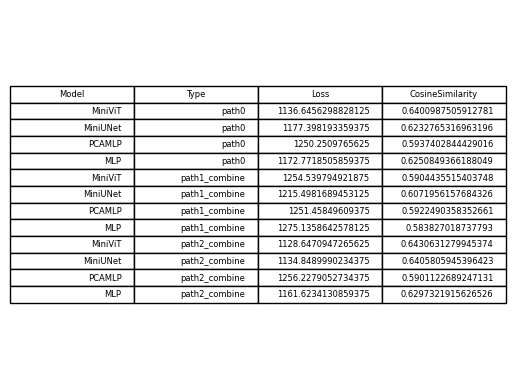

In [40]:
fig, ax = plt.subplots()
ax.axis('off')
table = ax.table(cellText=df_ns.values,
                 colLabels=df_ns.columns,
                 loc='center')
plt.savefig("table.png", bbox_inches='tight', dpi=600)

In [46]:
ms=load_all_model_families({"mms": mms}, save_dir="saved_models1")['mms']
ms2=load_all_model_families({"mms2": mms2}, save_dir="saved_models1")['mms2']
models_f=load_all_model_families({"models_full": models_full}, save_dir="saved_models1")['models_full']

✅ Loaded mms/MiniViT
✅ Loaded mms/MiniUNet
✅ Loaded mms/PCAMLP
✅ Loaded mms/MLP
✅ Loaded mms2/MiniViT
✅ Loaded mms2/MiniUNet
✅ Loaded mms2/PCAMLP
✅ Loaded mms2/MLP
✅ Loaded models_full/MiniViT
✅ Loaded models_full/MiniUNet
✅ Loaded models_full/PCAMLP
✅ Loaded models_full/MLP


In [47]:

def compute_loss_nm(x,y):
    return einsum(torch.square(x - y), 'b ... -> b')

In [48]:
path = GaussianConditionalProbabilityPath(
    p_data = MNISTSampler(),
    p_simple_shape = [1, 32, 32],
    alpha = LinearAlpha(),
    beta = LinearBeta()
)

In [49]:

z, y = path.p_data.sample(200) 
t = torch.rand(200,1,1,1).to(z)
x = path.sample_conditional_path(z,t) 
ut_ref = path.conditional_vector_field(x,z,t) 

In [53]:
loss.item()

RuntimeError: a Tensor with 200 elements cannot be converted to Scalar

In [85]:
result0=[]
for key, models_pair in models_f.items():
    model= models_pair
    model.eval()
    ut_theta = model(x, t=t, y=y)


    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss_nm(ut_theta,ut_ref).cpu().detach().numpy()
    print(f"  Loss: {loss.mean()}")
  
    result0.append({
        "Model": key,
        "Type": "path0",
  
        "Loss": loss if hasattr(loss, 'item') else loss

    })

Model: MiniViT
  Loss: 1130.64111328125
Model: MiniUNet
  Loss: 1170.44580078125
Model: PCAMLP
  Loss: 1352.8128662109375
Model: MLP
  Loss: 1167.1307373046875


In [ ]:

ms2=load_all_model_families({"mms2": mms2}, save_dir="saved_models1")['mms2']

In [86]:
ms=load_all_model_families({"mms": mms}, save_dir="saved_models1")['mms']
result1=[]
for key, models_pair in ms.items():
    model= models_pair
    model.eval()
    ut_theta = model(x, t=t, y=y)


    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss_nm(ut_theta,ut_ref).cpu().detach().numpy()
    print(f"  Loss: {loss.mean()}")
  
    result1.append({
        "Model": key,
        "Type": "path0",
  
        "Loss": loss if hasattr(loss, 'item') else loss

    })
ms2=load_all_model_families({"mms2": mms2}, save_dir="saved_models1")['mms2'] 
result2=[]
for key, models_pair in ms2.items():
    model= models_pair
    model.eval()
    ut_theta = model(x, t=t, y=y)


    print(f"Model: {key}")
    
    # Loss and MSE
    loss = compute_loss_nm(ut_theta,ut_ref).cpu().detach().numpy()
    print(f"  Loss: {loss.mean()}")
  
    result2.append({
        "Model": key,
        "Type": "path0",
  
        "Loss": loss if hasattr(loss, 'item') else loss

    })

✅ Loaded mms/MiniViT
✅ Loaded mms/MiniUNet
✅ Loaded mms/PCAMLP
✅ Loaded mms/MLP
Model: MiniViT
  Loss: 1251.642822265625
Model: MiniUNet
  Loss: 1211.508544921875
Model: PCAMLP
  Loss: 1251.374267578125
Model: MLP
  Loss: 1270.1256103515625
✅ Loaded mms2/MiniViT
✅ Loaded mms2/MiniUNet
✅ Loaded mms2/PCAMLP
✅ Loaded mms2/MLP
Model: MiniViT
  Loss: 1122.7850341796875
Model: MiniUNet
  Loss: 1130.1160888671875
Model: PCAMLP
  Loss: 1150.25634765625
Model: MLP
  Loss: 1154.2742919921875


In [110]:
from scipy.stats import ttest_ind,ttest_rel,mannwhitneyu,wilcoxon,ks_2samp




In [113]:
def compute_p_test(x,y):
    t_stat, p_value = ttest_ind(x, y, equal_var=False)
    return  t_stat, p_value 

def compute_p_test_rel(x,y):
    t_stat, p_value = ttest_rel(x, y)
    return  t_stat, p_value 

def compute_ks_d(x,y):
    t_stat, p_value =ks_2samp(x,y)
    return  t_stat, p_value 

def compute_u_test(x,y):
    t_stat, p_value =mannwhitneyu(x,y,alternative='two-sided')
    return  t_stat, p_value 


def compute_wilcoxon(x,y):
    t_stat, p_value =wilcoxon(x,y ,alternative='two-sided')
    return  t_stat, p_value 




In [ ]:
stat, p = mannwhitneyu(loss1, loss2, alternative='two-sided') stat, p = wilcoxon(loss1, loss2)stat, p = wilcoxon(loss1, loss2) stat, p = wilcoxon(loss1, loss2)

In [ ]:
from scipy.stats import ttest_rel
t_stat, p = ttest_rel(loss1, loss2)

In [ ]:
print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("✔ 有显著差异（p < 0.05）")
else:
    print("✘ 无显著差异（p ≥ 0.05）")

In [100]:
dres01=[]
dres02=[]
for i in range(len(result0)):
    
    print(f"Type path0 vs path1: ")
    print(f"Model: {result0[i]['Model']}")
    
    t_stat, p_value=compute_p_test(result0[i]['Loss'],result1[i]['Loss'])
    print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        r='reject'
    else :
         r=('fail to reject')
    print(r)
    
    dres01.append({
        'Type':"path0 vs path1",
        'Model':result0[i]['Model'],
        "result": r,

    })
    
    print(f"Type path0 vs path2: ")
    print(f"Model: {result0[i]['Model']}")
    
    t_stat, p_value=compute_p_test(result0[i]['Loss'],result2[i]['Loss'])
    print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        r='reject'
    else :
         r=('fail to reject')
    print(r)
    
    dres02.append({
        'Type':"path0 vs path2",
        'Model':result0[i]['Model'],
        "result": r,

    })
    
    
    

Type path0 vs path1: 
Model: MiniViT
t = -14.5056, p = 0.0000
reject
Type path0 vs path2: 
Model: MiniViT
t = 1.0183, p = 0.3092
fail to reject
Type path0 vs path1: 
Model: MiniUNet
t = -4.8072, p = 0.0000
reject
Type path0 vs path2: 
Model: MiniUNet
t = 4.5902, p = 0.0000
reject
Type path0 vs path1: 
Model: PCAMLP
t = 5.9688, p = 0.0000
reject
Type path0 vs path2: 
Model: PCAMLP
t = 12.3387, p = 0.0000
reject
Type path0 vs path1: 
Model: MLP
t = -10.6263, p = 0.0000
reject
Type path0 vs path2: 
Model: MLP
t = 1.6268, p = 0.1046
fail to reject


In [107]:
dres01

[{'Type': 'path0 vs path1', 'Model': 'MiniViT', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'MiniUNet', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'PCAMLP', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'MLP', 'result': 'reject'}]

In [108]:
dres02


[{'Type': 'path0 vs path2', 'Model': 'MiniViT', 'result': 'fail to reject'},
 {'Type': 'path0 vs path2', 'Model': 'MiniUNet', 'result': 'reject'},
 {'Type': 'path0 vs path2', 'Model': 'PCAMLP', 'result': 'reject'},
 {'Type': 'path0 vs path2', 'Model': 'MLP', 'result': 'fail to reject'}]

In [114]:
dres03=[]
dres04=[]
for i in range(len(result0)):
    
    #print(f"Type path0 vs path1: ")
    #print(f"Model: {result0[i]['Model']}")
    
    t_stat, p_value=compute_p_test_rel(result0[i]['Loss'],result1[i]['Loss'])
    #print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        r='reject'
    else :
         r=('fail to reject')
    #print(r)
    
    dres03.append({
        'Type':"path0 vs path1",
        'Model':result0[i]['Model'],
        "result": r,

    })
    
    #print(f"Type path0 vs path2: ")
    #print(f"Model: {result0[i]['Model']}")
    
    t_stat, p_value=compute_p_test_rel(result0[i]['Loss'],result2[i]['Loss'])
    #print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        r='reject'
    else :
         r=('fail to reject')
    #print(r)
    
    dres04.append({
        'Type':"path0 vs path2",
        'Model':result0[i]['Model'],
        "result": r,

    })

In [115]:
dres03


[{'Type': 'path0 vs path1', 'Model': 'MiniViT', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'MiniUNet', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'PCAMLP', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'MLP', 'result': 'reject'}]

In [116]:
dres04

[{'Type': 'path0 vs path2', 'Model': 'MiniViT', 'result': 'reject'},
 {'Type': 'path0 vs path2', 'Model': 'MiniUNet', 'result': 'reject'},
 {'Type': 'path0 vs path2', 'Model': 'PCAMLP', 'result': 'reject'},
 {'Type': 'path0 vs path2', 'Model': 'MLP', 'result': 'reject'}]

In [117]:
dres05=[]
dres06=[]
for i in range(len(result0)):
    
    #print(f"Type path0 vs path1: ")
    #print(f"Model: {result0[i]['Model']}")
    
    t_stat, p_value=compute_ks_d(result0[i]['Loss'],result1[i]['Loss'])
    #print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        r='reject'
    else :
         r=('fail to reject')
    #print(r)
    
    dres05.append({
        'Type':"path0 vs path1",
        'Model':result0[i]['Model'],
        "result": r,

    })
    
    #print(f"Type path0 vs path2: ")
    #print(f"Model: {result0[i]['Model']}")
    
    t_stat, p_value=compute_ks_d(result0[i]['Loss'],result2[i]['Loss'])
    #print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
    if p_value < 0.05:
        r='reject'
    else :
         r=('fail to reject')
    #print(r)
    
    dres06.append({
        'Type':"path0 vs path2",
        'Model':result0[i]['Model'],
        "result": r,

    })

In [118]:
dres05

[{'Type': 'path0 vs path1', 'Model': 'MiniViT', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'MiniUNet', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'PCAMLP', 'result': 'reject'},
 {'Type': 'path0 vs path1', 'Model': 'MLP', 'result': 'reject'}]

In [119]:
dres06

[{'Type': 'path0 vs path2', 'Model': 'MiniViT', 'result': 'fail to reject'},
 {'Type': 'path0 vs path2', 'Model': 'MiniUNet', 'result': 'reject'},
 {'Type': 'path0 vs path2', 'Model': 'PCAMLP', 'result': 'reject'},
 {'Type': 'path0 vs path2', 'Model': 'MLP', 'result': 'fail to reject'}]

# delta method && fisher info

In [ ]:
from torch.func import jacrev, vmap
def make_ffl(model):
    def f(x, y, t):
        out = model(x.unsqueeze(0), y=y.unsqueeze(0), t=t.unsqueeze(0))  # (1, s, d)
        #return rearrange(out, 'b s d -> (b s d)')  # 
        return rearrange(out.mean(-1),'b ... -> (b ...)')
    return f
def make_fil(model):
    def f(x):
        out = model(x.unsqueeze(0))  # (1, s, d)
        #return rearrange(out, 'b s d -> (b s d)')  # 
        return rearrange(out.mean(-1),'b ... ->(b ...)')
    return f
def make_fu(model):
    def f(x, y, t):
        out = model(x.unsqueeze(0), y=y.unsqueeze(0), t=t.unsqueeze(0))  # (1, s, d)
        #return rearrange(out, 'b s d -> (b s d)')  # 
        #return rearrange(out.mean(-1),'b ... -> b (...)')
        return out
    return f
def get_for_latent_mu_cov(model,x,t,y):
    mu=path.alpha(t)*x
    beta_sq=path.beta(t)**2
    f = make_ffl(model)
    f_mu=model(mu,t=t,y=y)
    jac=vmap(jacrev(f, argnums=0))(mu, y, t)
    #jac_flat=rearrange(jac.mean(0),'s c h w-> s ( c h w)')
    jac_flat = rearrange(jac, 'b s c h w -> b s (c h w)')
    f_cov=einsum( jac_flat, jac_flat,'b i k, b j k -> b i j')*beta_sq
    f_cov = f_cov.mean(0)
    return f_mu,f_cov
def get_inv_latent_mu_cov(model,x,t):
    mu=path.alpha.dt(t)*x
    beta_sq=path.beta.dt(t)**2
    f = make_fil(model)
    f_mu=model(mu)
    jac=vmap(jacrev(f, argnums=0))(mu)
    #jac_flat=rearrange(jac.mean(0),'s c h w-> s ( c h w)')
    #f_cov=einsum( jac_flat, jac_flat,'i k ,j k ...->i j')*beta_sq
    jac_flat = rearrange(jac, 'b s c h w -> b s (c h w)')
    f_cov=einsum( jac_flat, jac_flat,'b i k, b j k -> b i j')*beta_sq
    f_cov = f_cov.mean(0)
    
    return f_mu,f_cov
def make_cov_stable(f_cov):
    f_cov = (f_cov + f_cov.transpose(-1, -2)) / 2
    f_cov = f_cov + 1e-3 * torch.eye(f_cov.shape[-1], device=f_cov.device)
    return f_cov

def kl_gaussian_stable(mu1, cov1, mu2, cov2, eps=1e-4):
    d = mu1.shape[-1]
    cov1 = cov1 + eps * torch.eye(d, device=cov1.device)
    cov2 = cov2 +  eps * torch.eye(d, device=cov2.device)

    cov2_inv_cov1=torch.linalg.solve(cov2,cov1)
    trace=torch.trace(cov2_inv_cov1)
    
    delta_mu=(mu2-mu1)
    mahalanobis=delta_mu.T@torch.linalg.solve(cov2,delta_mu)
    
    log_det_cov1=torch.logdet(cov1)
    log_det_cov2=torch.logdet(cov2)
    log_det_ratio=log_det_cov2-log_det_cov1
    
    kl=0.5*(trace+ mahalanobis-d+log_det_ratio)
    return kl

f = make_ffl(forward_model)
g= make_fil(inverse_model)
jac1=vmap(jacrev(f, argnums=0))(x[:10], y[:10], t[:10])
jac2=vmap(jacrev(g, argnums=0))(ut_ref[:10])

l1mu,l1cov=get_for_latent_mu_cov(forward_model,z[:10],t[:10],y[:10])
l2mu,l2cov=get_inv_latent_mu_cov(inverse_model,z[:10],t[:10])
mu1=l1mu.mean(-1).mean(0)
mu2=l2mu.mean(-1).mean(0)
cov1=l1cov.mean(0)
cov2=l2cov.mean(0)
kl_gaussian_stable(mu2, cov2, mu1, cov1)
fisher1=l1cov/(rearrange(path.beta(t[:10]),'b 1 1 1 ->b 1 1') **4)
vmap(torch.trace)(fisher1)
torch.linalg.eigvalsh(fisher1)
torch.linalg.det(fisher1)